In [2]:
# Loadin and Saving of Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("FINAL_facebook_ads_dataset.csv")
df.info()
print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        10000 non-null  int64  
 1   page_id                   10000 non-null  int64  
 2   page_name                 10000 non-null  str    
 3   ad_delivery_start_time    10000 non-null  str    
 4   spend                     10000 non-null  str    
 5   impressions               10000 non-null  str    
 6   currency                  10000 non-null  str    
 7   demographic_distribution  9717 non-null   str    
 8   publisher_platforms       10000 non-null  str    
 9   bylines                   10000 non-null  str    
 10  estimated_audience_size   9999 non-null   str    
 11  ad_creative_bodies        10000 non-null  str    
 12  ad_delivery_stop_time     9884 non-null   str    
 13  avg_spend                 10000 non-null  float64
 14  avg_impressions   

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        10000 non-null  int64  
 1   page_id                   10000 non-null  int64  
 2   page_name                 10000 non-null  str    
 3   ad_delivery_start_time    10000 non-null  str    
 4   spend                     10000 non-null  str    
 5   impressions               10000 non-null  str    
 6   currency                  10000 non-null  str    
 7   demographic_distribution  9717 non-null   str    
 8   publisher_platforms       10000 non-null  str    
 9   bylines                   10000 non-null  str    
 10  estimated_audience_size   9999 non-null   str    
 11  ad_creative_bodies        10000 non-null  str    
 12  ad_delivery_stop_time     9884 non-null   str    
 13  avg_spend                 10000 non-null  float64
 14  avg_impressions   

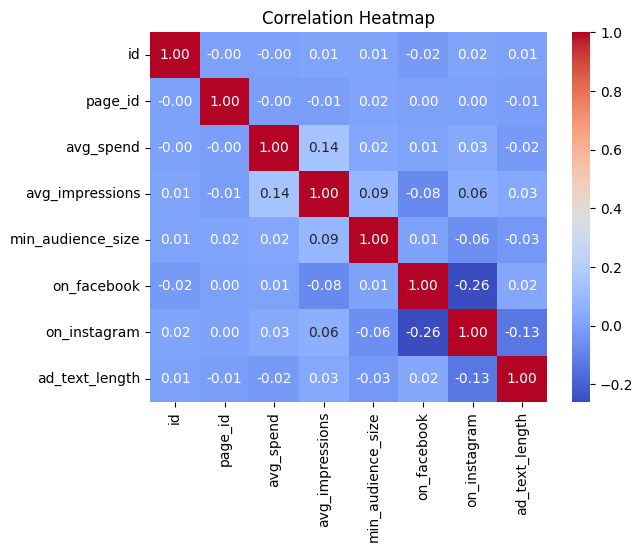

In [4]:
#EDA
df.info()
print(df.describe())
print(df.isnull().sum())

numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
print(corr_matrix)

#heatmap
plt.figure()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

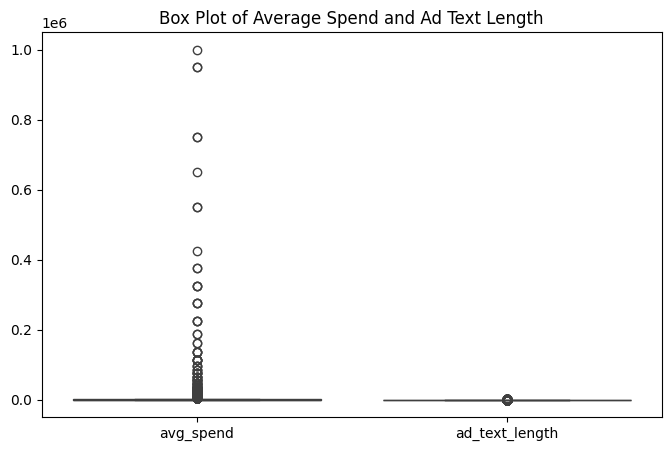

In [5]:
#BOXPLOT
plt.figure(figsize=(8,5))
sns.boxplot(data=df[['avg_spend','ad_text_length']])
plt.title("Box Plot of Average Spend and Ad Text Length")
plt.show()

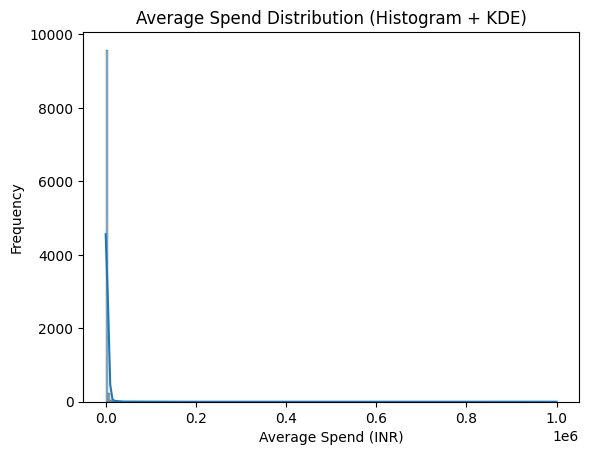

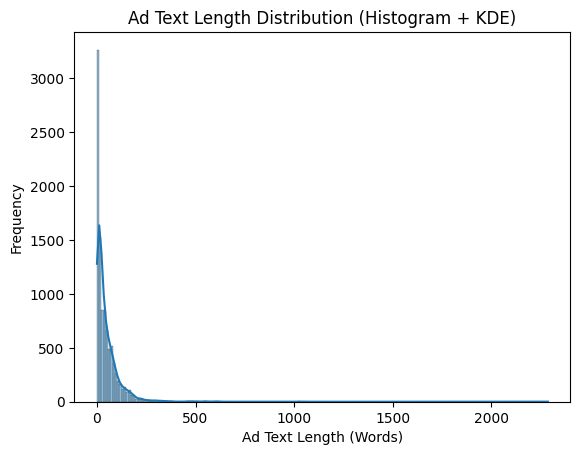

In [6]:
#Histogram
sns.histplot(df['avg_spend'],kde=True)
plt.title("Average Spend Distribution (Histogram + KDE)")
plt.xlabel("Average Spend (INR)")
plt.ylabel("Frequency")
plt.show()

sns.histplot(df['ad_text_length'],kde=True)
plt.title("Ad Text Length Distribution (Histogram + KDE)")
plt.xlabel("Ad Text Length (Words)")
plt.ylabel("Frequency")
plt.show()

In [7]:
#Outliers
Q1=df['ad_text_length'].quantile(0.25)
Q3=df['ad_text_length'].quantile(0.75)
IQR=Q3-Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("Lower Bound: ", lower_bound )
print("Upper Bound: ", upper_bound)
outliers=df[(df['ad_text_length']<lower_bound)|(df['ad_text_length']>upper_bound)]
print("Number of outliers in text length: ",len(outliers))
df_clean=df[(df['ad_text_length']>=lower_bound)&(df['ad_text_length']<=upper_bound)]
print("Original Data Shape: ",df.shape)
print("Cleaned Data Shape:", df_clean.shape)

Lower Bound:  -81.5
Upper Bound:  154.5
Number of outliers in text length:  565
Original Data Shape:  (10000, 21)
Cleaned Data Shape: (9435, 21)
